# Mathematics by Computer: Year-Long Machine Learning Project (excerpt)
*Author:* Gabriella Harrison\
*Purpose:* Demonstrate data manipulation, visualization, and modelling.
- Task A1: Linear regression with scikit-learn on SeoulBikeData_mod.csv (if present)
- Task A2: Linear regression from scratch with NumPy on a 3-point toy dataset

### Task A1 - Linear Regression on Seoul Bike Data Set (adapted)

In a recent research article published in the journal Computer Communications, authors Sathishkumar V E, Jangwoo Park, and Yongyun Cho sought to predict the "bike count required at each hour for the stable supply of rental bikes"[1]. They employed several regression models, including linear regression. The dataset used in the original study is available [here](https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand).

**Task:** Apply machine learning to a modified version of the original dataset and report the results.


[1] Sathishkumar V E, Jangwoo Park, and Yongyun Cho. 'Using data mining techniques for bike sharing demand prediction in metropolitan city.' Computer Communications, Vol.153, pp.353-366, March, 2020 [web link](https://doi.org/10.1016/j.comcom.2020.02.007).

---

The original research article and a modified dataset are posted on the MA124 Moodle page in the resources for this project (File linked here: [web link] (https://moodle.warwick.ac.uk/pluginfile.php/4157578/mod_folder/content/0/SeoulBikeData_mod.csv?forcedownload=1) . You will need to refer to the article for some of the tasks below. You will need to download SeoulBikeData_mod.csv and put it into the folder with this file.

SeoulBikeData_mod.csv has been modified from the original dataset to remove the categorical variables, and to convert dates to months. Months have been coded by number, e.g. 1 = January, etc. Only half the months are included in the modified dataset.

---
**Purpose:**
- Histogram of "Rented Bike Count"
- Boxplot of "Rented Bike Count"
- Create Test/Train split
- Utilize Scikitlearn to train and evaluate model
- Generate additional plots for further analysis

In [2]:
#Task 1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import sklearn
from sklearn import datasets
from sklearn import linear_model

In [3]:
#Task 2
seoul_bikes = pd.read_csv("SeoulBikeData_mod.csv")
print(type(seoul_bikes))

<class 'pandas.core.frame.DataFrame'>


In [3]:
#Task 2
seoul_bikes = pd.read_csv("SeoulBikeData_mod.csv")
print(type(seoul_bikes))

<class 'pandas.core.frame.DataFrame'>


In [4]:
#Task 3
seoul_bikes.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Month
count,4416.000000,4416.00000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000,4416.000000
mean,704.591259,11.50000,13.203986,59.257246,1.653193,1398.641304,4.723958,0.560181,0.139312,0.070879,5.956522
std,637.407244,6.92297,11.529724,20.162981,0.976361,621.560536,12.671445,0.860496,1.145271,0.437416,3.407262
min,0.000000,0.00000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,1.000000
25%,189.000000,5.75000,4.500000,44.000000,0.900000,853.000000,-3.500000,0.000000,0.000000,0.000000,3.000000
50%,542.000000,11.50000,14.300000,58.000000,1.500000,1621.000000,6.400000,0.010000,0.000000,0.000000,5.000000
75%,1047.000000,17.25000,22.200000,75.000000,2.200000,1999.000000,14.900000,0.910000,0.000000,0.000000,9.000000
max,3298.000000,23.00000,38.000000,98.000000,6.700000,2000.000000,26.800000,3.520000,35.000000,8.800000,11.000000


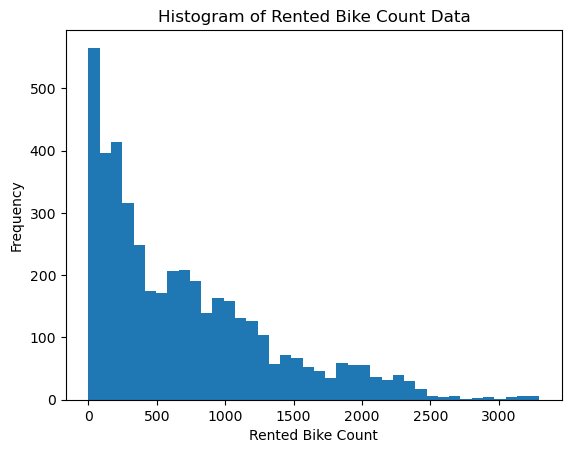

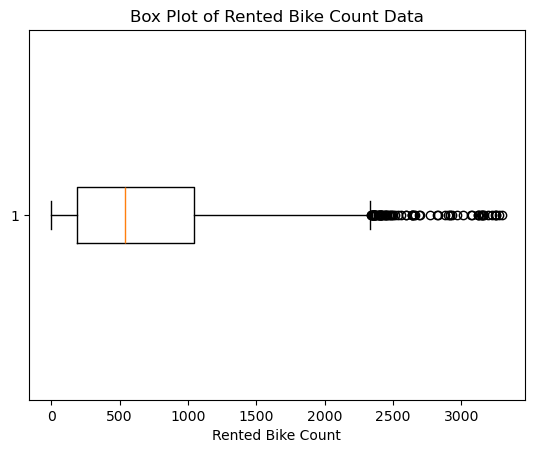

In [5]:
#Task 4
rented_bike_count = seoul_bikes["Rented Bike Count"] #pulls data from single column of rented bike count

plt.hist(rented_bike_count, bins = 40, density = False) #plots histogram
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.title("Histogram of Rented Bike Count Data")
plt.show()

plt.boxplot(rented_bike_count, vert = False) #plots boxplot (horizontally)
plt.xlabel("Rented Bike Count")
plt.title("Box Plot of Rented Bike Count Data")
plt.show()

In [6]:
#Task 5
y = seoul_bikes["Rented Bike Count"] #takes data just from rented bike count column
X = seoul_bikes.drop(["Rented Bike Count"], axis = 1) #drops the rented bike column, but keeps rest of data

#X is design matrix
#y is target matrix

In [7]:
#Task 6
#percent of data for testing/training:
#75% used for training, 25% used for testing (pg 5 of paper)

print("X shape is", X.shape) #checking sizes of data to help with split
print("y shape is", y.shape)

#75% of X is the first 3312 rows (of 4416)
X_train = X[0:3312]
#then 25% is the rest of them
X_test = X[3312:4416]
print("X train shape is", X_train.shape) #checking sizes again
print("X test shape is", X_test.shape)

#same for the y dataset
y_train = y[0:3312]
y_test = y[3312:4416]
print("y train shape is", y_train.shape)
print("y test shape is", y_test.shape)

X shape is (4416, 10)
y shape is (4416,)
X train shape is (3312, 10)
X test shape is (1104, 10)
y train shape is (3312,)
y test shape is (1104,)


In [8]:
#Task 7
lin_reg_model =linear_model.LinearRegression() #creating the model
lin_reg_model.fit(X_train, y_train) #train model using data

LinearRegression()

In [9]:
#Task 8
y_pred = lin_reg_model.predict(X_test) #finding prediction with test data

resid = y_test-y_pred

In [10]:
#Task 9

#R^2 value
R2_value = sklearn.metrics.r2_score(y_test, y_pred)
print("The R2 value is", R2_value)
##This is much different than 0.55 in the paper. Modified dataset causes
##changes.

#RMSE
RMSE_value = sklearn.metrics.root_mean_squared_error(y_test, y_pred)
print("The RMSE value is", RMSE_value)
##This is fairly similar to 427.71 in paper

#Mean absolute error
MAE_value = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print("The MAE value is", MAE_value)
##This is fairly similar to 322.32 in paper

#Coefficient of Variation
#CV = RMSE/mean *100
mean = np.mean(y_test)
CV_value = (RMSE_value/mean)*100
print("The CV value is", CV_value)
##This is fairly similar to the 61.03 in the paper

The R2 value is 0.09365467992826082
The RMSE value is 546.1983395427225
The MAE value is 404.5364341012174
The CV value is 80.92576565129697


$$\textbf{Commentary on Statistical Measures}$$
When calculating the statistical measures for the Seoul Bike dataset, most values appear to be similar to those found in the original study [1]. However, since this dataset has been modified from the original, slight variation is expected. The calculated $R^2$ value is 0.0936, which represents a very low correlation between the predicted values and actual values (based on the calculations done by the linear regression model). This is much lower than the $R^2$ value of 0.55 in the reference paper [1]. The calculated Root Mean Squared Error value is 546.198, which is relatively similar to the value 427.71 in the reference paper [1]. The calculated Mean Absolute Error is 404.536, which is also similar to the value of 322.32 in the reference paper [1]. Finally, the calculated Coefficient of Variation is 80.926, which is similar to the value of 61.03 in the reference paper [1]. Most statistics were relatively similar to those found in the reference paper, validating the model shown [1]. However, the very low $R^2$ value denotes a low correlation between the model's predictions and the actual values, making the results less trustworthy.

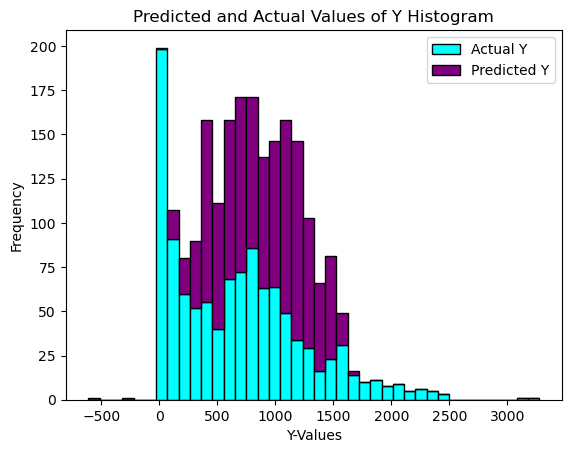

In [11]:
#Task 10

#histogram for y_test and y_pred
plt.hist([y_test, y_pred], bins = 40, density = False, stacked = True, color = ["cyan", "Purple"],
        edgecolor = "black")
plt.xlabel("Y-Values")
plt.ylabel("Frequency")
plt.title("Predicted and Actual Values of Y Histogram")
plt.legend(["Actual Y", "Predicted Y"])
plt.show()

$$\textbf{Commentary on Predicted and Actual Values of Y Histogram}$$
The predicted y tends to over-predict most of the values for y, as demonstrated by the higher frequency of y-values for values in the range of about 300-1500. Further, the predicted y-values are heavily clustered in the range of about 300-1500, while the actual y-values tend to be more distributed between 0 and 2500. Additionally, the predicted y-value has considerably accurate frequencies in the range of about 0-300.

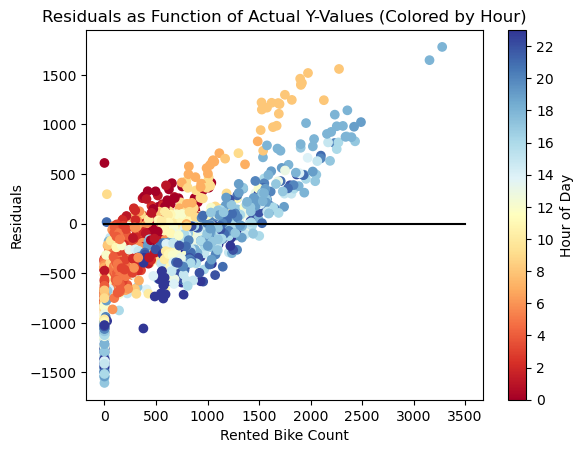

In [12]:
#scatter plot of resid as func of y_test (Fig 9),
#use colormap to plot hours different colors

hours = X_test["Hour"] #define the hours data separately
plt.scatter(y_test, resid,c = hours, cmap = "RdYlBu") #make the scatter plot

cbar = plt.colorbar() #adding legend on side for hours (for more analysis)
cbar.set_label("Hour of Day")
cbar.set_ticks(range(0,24,2))

plt.plot([0,3500], [0,0], color = 'k') #adding horizontal line for axis/analysis

plt.xlabel("Rented Bike Count")
plt.ylabel("Residuals")
plt.title("Residuals as Function of Actual Y-Values (Colored by Hour)")
plt.show()

$$\textbf{Commentary on Residuals as a Function of Actual Y-Values Scatter Plot}$$

The residuals have a general positive linear correlation with rented bike count. Hence, as the number of bikes rented increases, the likelihood of the model being accurate decreases. In the first half of the day (denoted by the redder shades of datapoints), the number of rented bikes is clustered at low levels (under 1000 bikes). In the later half of the day (denoted by blue-toned data points), the distribution of number of rented bikes is much more spread, ranging primarily from about 500 bikes to 2500 bikes. There are distinct clusters for the rented bike count in the first half of the day and for the rented bike count in the second half of the day.


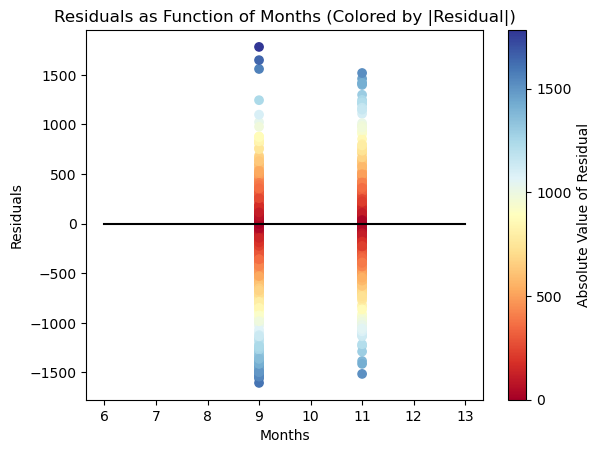

In [13]:
#scatter plot of resid as func of X_test["month"],
#use colormap to indicate abs val of resid

months = X_test["Month"] #define month data section separately

absval_resid = np.abs(resid) #defining absval of resid separately

plt.scatter(months, resid,c = absval_resid, cmap = "RdYlBu") #make the scatter plot

cbar = plt.colorbar() #adding legend on side for residuals (for more analysis)
cbar.set_label("Absolute Value of Residual")
cbar.set_ticks(range(0,1800,500)) #values taken from finding min/max of absval_resid

plt.plot([6,13], [0,0], color = 'k') #adding horizontal line for axis/analysis

plt.xlabel("Months")
plt.ylabel("Residuals")
plt.title("Residuals as Function of Months (Colored by |Residual|)")
plt.show()

$$ \textbf{Commentary on Residuals as a Function of Months Scatter Plot}$$
The residuals are symmetric about zero per month, which demonstrates limited bias in the model towards over-prediction or under-prediction. This improves the reliability of the model. However, there is a large spread of residuals, indicating somewhat inconsistent and inaccurate predictions from the linear model. As expected, the color gradient denoting the absolute value of the residual is also symmetric.

Note - The months before month nine were included in the training data, so it is not shown on the plot (which shows only test data).

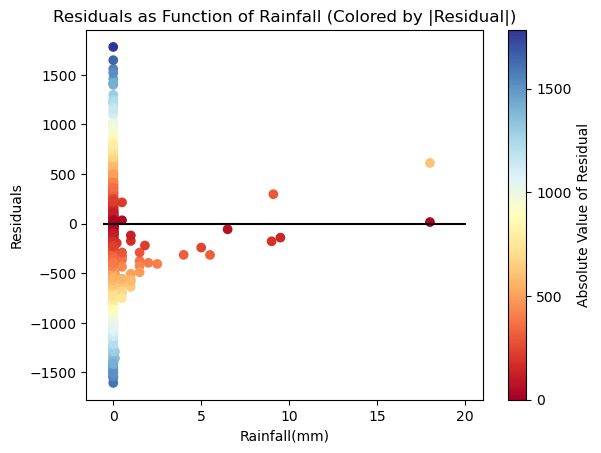

In [14]:
#scatter plot of resid as func of rainfall

rainfall = X_test["Rainfall(mm)"] #defining rainfall separately

#absval was previously defined so its fine

plt.scatter(rainfall, resid,c = absval_resid, cmap = "RdYlBu") #make the scatter plot

cbar = plt.colorbar() #adding legend on side for residuals (for more analysis)
cbar.set_label("Absolute Value of Residual")
cbar.set_ticks(range(0,1800,500)) #values taken from finding min/max of absval_resid

plt.plot([-0.5,20], [0,0], color = 'k') #adding horizontal line for axis/analysis

plt.xlabel("Rainfall(mm)")
plt.ylabel("Residuals")
plt.title("Residuals as Function of Rainfall (Colored by |Residual|)")
plt.show()

$$\textbf{Commentary on Residuals as a Function of Rainfall Scatter Plot}$$

There is large variation in residuals for data points where there was zero millimeters of rainfall. This could indicate that a vast amount of the data is clustered at zero rainfall, skewing the model's ability to accurately predict data points. As the rainfall amount increases, the residuals loosely trend towards zero. This demonstrates the model's higher reliability in predicting bike rentals when higher rainfall is present. The heavy cluster of points at rainfall levels less than five millimeters could also hint at the climate where the data was collected.

### Task A2 Linear Regression on a toy dataset from scratch utilizing solely numpy (adapted)

Consider a really small dataset consisting of only three points in the plane: $(1,1),(2,4),(3,5)$.

For each point (training example) consider the $x$-coordinate as a single input feature, and the $y$-coordinate as the output or label of the example. The **objective** is to find the best line to fit these data. Here 'best' will mean the line which minimises the mean of the sum of the squares of the residuals with respect to the three points.

The model here is a simple linear model

$$
\hat y = mx +c
$$

with trainable parameters $m$ and $c$. The goal is to find the optimal values of $m$ and $c$ to fit these training data. 

**Purpose**:
- Write equations for cost function.
- Apply Gradient Descent via a function to optimize parameters $m$ and $c$.
- Plot the datapoints along with the optimal line.

**1)** **Loss function for (1,1):** \
       \begin{equation*} \begin{split}L(m(1)+c,1) &= L(m+c, 1)\\
        &= (m+c-1)^2\\
        &= m^2 + 2mc - 2m +c^2 - 2c + 1 \end{split} \end{equation*} \
   **Loss function for (2,4):** \
       \begin{equation*}\begin{split}
       L(m(2)+c,4) &= L(2m+c, 4)\\
       & = (2m+c-4)^2 \\
       &= 4m^2 + 4mc - 16m +c^2 - 8c + 16 \end{split}\end{equation*} \
   **Loss function for (3,5):**\
       \begin{equation*}\begin{split} L(m(3)+c,5) &= L(3m+c, 5)\\
       &= (3m+c-5)^2\\
       &= 9m^2 + 6mc - 30m +c^2 - 10c + 25 \end{split}\end{equation*}

   The cost function is the mean of these 3 losses:\
   $$J=\frac{L(m+c, 1) + L(2m+c, 4) + L(3m+c, 5)}{3} = \frac{m^2 + 2mc - 2m +c^2 - 2c + 1 + 4m^2 + 4mc - 16m +c^2 - 8c + 16 + 9m^2 + 6mc - 30m +c^2 - 10c + 25}{3} $$
   Simplifying by collecting terms, we get:\
   $$ J = \frac{14m^2 + 12mc - 48m + 3c^2 - 20c + 42}{3} $$
   as required.


**2)** The partial derivatives are as follows:\
 $\frac{\partial J}{\partial m} = \frac{28m + 12c - 48}{3}$ \
   $\frac{\partial J}{\partial c} = \frac{12m + 6c - 20}{3}$


In [15]:
# Part 3
from numpy import random #Needed to generate random m and c between -2 and 2

def partial_derivatives(m_, c): # Calculates the partial derivatives using formulas found in part 2.
  Jm = (28*m_+12*c-48)/3
  Jc = (12*m_+6*c-20)/3
  return(Jm, Jc)

def cost(m_,c): # Calculates the cost function using expression from part 1.
  J = (14*(m_**2) + 12*m_*c -48*m_ + 3*(c**2) - 20*c +42)/3
  return(J)

def model1(alpha, num_iterations):
  m_ = random.uniform(-2,2)
  c = random.uniform(-2,2)
  for i in range(0, num_iterations):
    partial_m, partial_c = partial_derivatives(m_,c)
    if i%(num_iterations//5) == 0:
      print(cost(m_,c)) # Returns cost function 5 times during the iterations.
    m_ = m_ - partial_m*alpha
    c = c - partial_c*alpha
  return(m_,c)

print("The final values for m and c are:", model1(0.1, 1000))


5.7501455966613735
0.22226812384526795
0.22222222494340352
0.22222222222238486
0.2222222222222238
The final values for m and c are: (1.9999999999723452, -0.666666666603801)


In [15]:
# Part 3
from numpy import random #Needed to generate random m and c between -2 and 2

def partial_derivatives(m_, c): # Calculates the partial derivatives using formulas found in part 2.
  Jm = (28*m_+12*c-48)/3
  Jc = (12*m_+6*c-20)/3
  return(Jm, Jc)

def cost(m_,c): # Calculates the cost function using expression from part 1.
  J = (14*(m_**2) + 12*m_*c -48*m_ + 3*(c**2) - 20*c +42)/3
  return(J)

def model1(alpha, num_iterations):
  m_ = random.uniform(-2,2)
  c = random.uniform(-2,2)
  for i in range(0, num_iterations):
    partial_m, partial_c = partial_derivatives(m_,c)
    if i%(num_iterations//5) == 0:
      print(cost(m_,c)) # Returns cost function 5 times during the iterations.
    m_ = m_ - partial_m*alpha
    c = c - partial_c*alpha
  return(m_,c)

print("The final values for m and c are:", model1(0.1, 1000))


5.7501455966613735
0.22226812384526795
0.22222222494340352
0.22222222222238486
0.2222222222222238
The final values for m and c are: (1.9999999999723452, -0.666666666603801)


1.2314266558795879
0.5957314851562501
0.3648463415306864
0.27668309221169335
0.2430180481624049


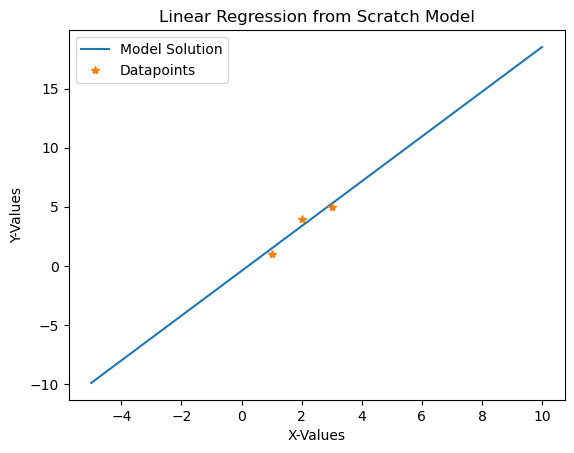

In [16]:
  # Part 4
import numpy as np
import matplotlib.pyplot as plt

# Plot optimal line
x = np.linspace(-5,10,301)
m_,c = model1(0.01,1000)
y = m_*x + c
plt.plot(x,y)

#Plot datapoints
x_train = np.array([1,2,3])
y_TRAIN = np.array([1,4,5])
plt.plot(x_train, y_TRAIN, '*') #use different data name than the one in A1
plt.xlabel("X-Values")
plt.ylabel("Y-Values")
plt.title("Linear Regression from Scratch Model")
plt.legend(["Model Solution", "Datapoints"])
plt.show()